### Step 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

TUNED_CKPT = CKPT_DIR / "lr5e4_base24_bs2_cont_to_50_best.pt"
MIXED_CKPT = CKPT_DIR / "ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("TUNED_CKPT exists:", TUNED_CKPT.exists())
print("MIXED_CKPT exists:", MIXED_CKPT.exists())

Mounted at /content/drive
device: cuda
VAL_MANIFEST exists: True
TUNED_CKPT exists: True
MIXED_CKPT exists: True


### Step 2 — Optional title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Tuned vs Mixed Evaluation
## Mixed run: ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3
"""))


# CT-to-Dose Phase 4: Tuned vs Mixed Evaluation
## Mixed run: ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3


### Step 3 — Dataset + model definitions

In [3]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)

        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b  = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Prediction helpers

In [4]:
@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]
    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()
    gt_vol = x1.squeeze().numpy()
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    slice_2d = volume[slice_idx]
    peak_idx = np.unravel_index(np.argmax(slice_2d), slice_2d.shape)
    return peak_idx

### Step 5 — Percentage-error helpers

In [5]:
def compute_profile_percentage_error(
    gt_curve,
    pred_curve,
    mode="relative_to_curve_max",
    threshold=0.01,
    eps=1e-8,
    return_mask=False
):
    gt_curve = np.asarray(gt_curve, dtype=np.float64)
    pred_curve = np.asarray(pred_curve, dtype=np.float64)

    if mode == "relative_to_curve_max":
        ref = float(np.max(gt_curve))
        relevant_threshold = max(threshold * ref, eps)
    elif mode == "absolute":
        relevant_threshold = max(float(threshold), eps)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    valid_mask = gt_curve >= relevant_threshold

    pct_err = np.full_like(gt_curve, np.nan, dtype=np.float64)
    pct_err[valid_mask] = (
        100.0 * np.abs(pred_curve[valid_mask] - gt_curve[valid_mask]) /
        np.maximum(gt_curve[valid_mask], eps)
    )

    if return_mask:
        return pct_err, valid_mask, relevant_threshold
    return pct_err


def summarize_profile_percentage_error(
    gt_profile,
    pred_profile,
    mode="relative_to_curve_max",
    threshold=0.01,
    eps=1e-8
):
    pct_error, mask, relevant_threshold = compute_profile_percentage_error(
        gt_profile,
        pred_profile,
        mode=mode,
        threshold=threshold,
        eps=eps,
        return_mask=True
    )

    if np.any(mask):
        mean_pct = float(np.nanmean(pct_error))
        max_pct = float(np.nanmax(pct_error))
        valid_count = int(np.sum(mask))
        total_count = int(len(mask))
    else:
        mean_pct = np.nan
        max_pct = np.nan
        valid_count = 0
        total_count = int(len(mask))

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "pct_error_curve": pct_error,
        "mask": mask,
        "valid_count": valid_count,
        "total_count": total_count,
        "relevant_threshold": relevant_threshold,
    }

### Step 6 — Plot helpers

In [6]:
def save_cross_section_with_matched_scales(
    ct_vol,
    gt_vol,
    pred_vol,
    slice_idx,
    save_path,
    title_prefix=""
):
    ct_slice = ct_vol[slice_idx]
    gt_slice = gt_vol[slice_idx]
    pred_slice = pred_vol[slice_idx]
    abs_diff = np.abs(pred_slice - gt_slice)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(ct_slice, cmap="gray")
    axes[0].set_title(f"{title_prefix} Input CT")
    axes[0].axis("off")

    im1 = axes[1].imshow(gt_slice, cmap="hot")
    axes[1].set_title(f"{title_prefix} Ground Truth")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(pred_slice, cmap="hot", vmin=gt_slice.min(), vmax=gt_slice.max())
    axes[2].set_title(f"{title_prefix} Prediction")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(abs_diff, cmap="hot")
    axes[3].set_title(f"{title_prefix} Abs Difference")
    axes[3].axis("off")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()


def plot_profile_with_percentage_error(
    gt_curve,
    pred_curve,
    title,
    xlabel,
    save_path,
    pct_mode="relative_to_curve_max",
    pct_threshold=0.01,
    eps=1e-8
):
    abs_diff = np.abs(gt_curve - pred_curve)

    pct_summary = summarize_profile_percentage_error(
        gt_curve,
        pred_curve,
        mode=pct_mode,
        threshold=pct_threshold,
        eps=eps
    )

    pct_curve = pct_summary["pct_error_curve"]
    mean_pct = pct_summary["mean_pct_error"]
    max_pct = pct_summary["max_pct_error"]
    valid_count = pct_summary["valid_count"]
    total_count = pct_summary["total_count"]
    relevant_threshold = pct_summary["relevant_threshold"]

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

    axes[0].plot(gt_curve, label="Ground Truth")
    axes[0].plot(pred_curve, label="Prediction")
    axes[0].plot(abs_diff, label="Abs Difference")
    axes[0].set_title(title)
    axes[0].set_ylabel("Dose")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(pct_curve, label="Percentage Error (%)")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Percentage Error (%)")
    axes[1].grid(True)
    axes[1].legend()

    if valid_count > 0:
        axes[1].set_title(
            f"Mean % error = {mean_pct:.3f}, Max % error = {max_pct:.3f} "
            f"(valid {valid_count}/{total_count}, thr={relevant_threshold:.4g})"
        )
    else:
        axes[1].set_title("Percentage Error: no valid region above threshold")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "valid_count": valid_count,
        "total_count": total_count,
        "relevant_threshold": relevant_threshold,
    }

### Step 7 — Analyze one case

In [7]:
def analyze_one_case(dataset, sample_idx, model, device, out_dir, prefix):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(model, dataset, sample_idx, device, n_steps=30)

    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    save_cross_section_with_matched_scales(
        ct_vol,
        gt_vol,
        pred_vol,
        slice_idx,
        out_dir / f"{prefix}_cross_section.png",
        title_prefix=prefix.replace("_", " ").title()
    )

    gt_along = gt_vol[slice_idx, peak_y, :]
    pred_along = pred_vol[slice_idx, peak_y, :]
    along_stats = plot_profile_with_percentage_error(
        gt_along,
        pred_along,
        f"{prefix.replace('_', ' ').title()}: Along-Beam Profile",
        "x index (approx. beam direction)",
        out_dir / f"{prefix}_along_beam_profile_with_pct_error.png",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01
    )

    gt_perp = gt_vol[slice_idx, :, peak_x]
    pred_perp = pred_vol[slice_idx, :, peak_x]
    perp_stats = plot_profile_with_percentage_error(
        gt_perp,
        pred_perp,
        f"{prefix.replace('_', ' ').title()}: Perpendicular Profile",
        "y index (perpendicular to beam)",
        out_dir / f"{prefix}_perpendicular_profile_with_pct_error.png",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01
    )

    mse = float(np.mean((pred_vol - gt_vol) ** 2))
    mae = float(np.mean(np.abs(pred_vol - gt_vol)))
    rel_err_pct = float(100.0 * np.sum(np.abs(pred_vol - gt_vol)) / (np.sum(np.abs(gt_vol)) + EPS))

    result = {
        "sample_idx": sample_idx,
        "best_slice": slice_idx,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "gt_max": float(gt_vol.max()),
        "mse": mse,
        "mae": mae,
        "relative_error_pct": rel_err_pct,

        "along_mean_pct_error": along_stats["mean_pct_error"],
        "along_max_pct_error": along_stats["max_pct_error"],
        "along_valid_count": along_stats["valid_count"],
        "along_total_count": along_stats["total_count"],
        "along_relevant_threshold": along_stats["relevant_threshold"],

        "perp_mean_pct_error": perp_stats["mean_pct_error"],
        "perp_max_pct_error": perp_stats["max_pct_error"],
        "perp_valid_count": perp_stats["valid_count"],
        "perp_total_count": perp_stats["total_count"],
        "perp_relevant_threshold": perp_stats["relevant_threshold"],
    }

    return result

### Step 8 — Evaluation metrics

In [8]:
THRESHOLD = 0.15
THRESHOLD_MODE = "absolute"

def get_case_threshold(gt_vol, threshold=0.15, mode="absolute"):
    if mode == "absolute":
        T = float(threshold)
    elif mode == "relative_to_case_max":
        T = float(threshold) * float(gt_vol.max())
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return max(T, 1e-8)

def compute_weighted_eval_metrics(gt_vol, pred_vol, threshold=0.15, mode="absolute"):
    T = get_case_threshold(gt_vol, threshold=threshold, mode=mode)

    abs_err = np.abs(pred_vol - gt_vol)
    sq_err = (pred_vol - gt_vol) ** 2

    weight = np.maximum(T, gt_vol) / T
    weighted_mse = float(np.mean(weight * sq_err))

    high_mask = gt_vol >= T
    outside_mask = gt_vol < T

    gt_max = float(gt_vol.max())
    peak_core_mask = gt_vol >= (0.8 * gt_max)
    peak_shoulder_mask = (gt_vol >= 0.3 * gt_max) & (gt_vol < 0.8 * gt_max)

    def safe_mean(arr):
        return float(np.mean(arr)) if arr.size > 0 else np.nan

    def safe_max(arr):
        return float(np.max(arr)) if arr.size > 0 else np.nan

    def safe_p95(arr):
        return float(np.percentile(arr, 95)) if arr.size > 0 else np.nan

    return {
        "overall_mse": float(np.mean(sq_err)),
        "overall_mae": float(np.mean(abs_err)),
        "weighted_mse": weighted_mse,

        "high_mse": safe_mean(sq_err[high_mask]),
        "high_mae": safe_mean(abs_err[high_mask]),

        "outside_mse": safe_mean(sq_err[outside_mask]),
        "outside_mae": safe_mean(abs_err[outside_mask]),
        "outside_max_abs_error": safe_max(abs_err[outside_mask]),
        "outside_p95_abs_error": safe_p95(abs_err[outside_mask]),

        "peak_core_mae": safe_mean(abs_err[peak_core_mask]),
        "peak_shoulder_mae": safe_mean(abs_err[peak_shoulder_mask]),

        "threshold_used": T,
        "num_high_voxels": int(high_mask.sum()),
        "num_outside_voxels": int(outside_mask.sum()),
    }

### Step 9 — Load dataset and models

In [9]:
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

tuned_ckpt = torch.load(TUNED_CKPT, map_location="cpu")
mixed_ckpt = torch.load(MIXED_CKPT, map_location="cpu")

tuned_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
mixed_model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)

tuned_model.load_state_dict(tuned_ckpt["model_state_dict"])
mixed_model.load_state_dict(mixed_ckpt["model_state_dict"])

tuned_model.eval()
mixed_model.eval()

print("Validation samples:", len(val_dataset_3d))
print("Models loaded successfully.")

Validation samples: 500
Models loaded successfully.


### Step 10 — Full casewise comparison

In [10]:
all_rows = []

for idx in range(len(val_dataset_3d)):
    ct_vol, gt_vol, tuned_pred = get_flow_prediction(
        tuned_model, val_dataset_3d, idx, device, n_steps=30
    )
    tuned_metrics = compute_weighted_eval_metrics(
        gt_vol, tuned_pred,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE
    )
    all_rows.append({
        "model": "tuned",
        "sample_idx": idx,
        **tuned_metrics
    })

    _, _, mixed_pred = get_flow_prediction(
        mixed_model, val_dataset_3d, idx, device, n_steps=30
    )
    mixed_metrics = compute_weighted_eval_metrics(
        gt_vol, mixed_pred,
        threshold=THRESHOLD,
        mode=THRESHOLD_MODE
    )
    all_rows.append({
        "model": "mixed",
        "sample_idx": idx,
        **mixed_metrics
    })

comparison_df = pd.DataFrame(all_rows)

comparison_csv = OUT_DIR / "ct2dose_phase4_mixed_vs_tuned_casewise_metrics_T0p15_a0p30_mw3.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved:", comparison_csv)
display(comparison_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_phase4_mixed_vs_tuned_casewise_metrics_T0p15_a0p30_mw3.csv


,model,sample_idx,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,tuned,0,0.000015,0.002473,0.000045,0.000079,0.005866,0.000010,0.002226,0.033033,0.006531,0.116184,0.040654,0.15,2224,30544
1,mixed,0,0.000023,0.003124,0.000058,0.000142,0.009714,0.000014,0.002644,0.031866,0.007942,0.134365,0.034779,0.15,2224,30544
2,tuned,1,0.000024,0.002947,0.000062,0.000108,0.006519,0.000019,0.002744,0.048242,0.009180,0.119688,0.050971,0.15,1763,31005
3,mixed,1,0.000021,0.003012,0.000035,0.000057,0.005417,0.000019,0.002876,0.051075,0.008841,0.075141,0.026899,0.15,1763,31005
4,tuned,2,0.000019,0.003152,0.000021,0.000062,0.005842,0.000018,0.003080,0.057801,0.008533,0.005584,0.010694,0.15,856,31912


### Step 11 — Summary table

In [11]:
summary_df = comparison_df.groupby("model").agg({
    "overall_mse": "mean",
    "overall_mae": "mean",
    "weighted_mse": "mean",
    "high_mse": "mean",
    "high_mae": "mean",
    "outside_mse": "mean",
    "outside_mae": "mean",
    "outside_max_abs_error": "mean",
    "outside_p95_abs_error": "mean",
    "peak_core_mae": "mean",
    "peak_shoulder_mae": "mean",
}).reset_index()

summary_csv = OUT_DIR / "ct2dose_phase4_mixed_vs_tuned_summary_T0p15_a0p30_mw3.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_phase4_mixed_vs_tuned_summary_T0p15_a0p30_mw3.csv


,model,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae
0,mixed,0.000018,0.002737,0.000028,0.000086,0.006276,0.000015,0.002566,0.036794,0.007547,0.047260,0.019714
1,tuned,0.000017,0.002662,0.000029,0.000089,0.006105,0.000014,0.002506,0.033767,0.007345,0.047654,0.022622


### Step 12 — Select best / typical / worst from tuned

In [12]:
tuned_only = comparison_df[comparison_df["model"] == "tuned"].copy()
tuned_only = tuned_only.sort_values("weighted_mse").reset_index(drop=True)

best_case_idx = int(tuned_only.iloc[0]["sample_idx"])
typical_case_idx = int(tuned_only.iloc[len(tuned_only) // 2]["sample_idx"])
worst_case_idx = int(tuned_only.iloc[-1]["sample_idx"])

print("best_case_idx   =", best_case_idx)
print("typical_case_idx=", typical_case_idx)
print("worst_case_idx  =", worst_case_idx)

best_case_idx   = 496
typical_case_idx= 273
worst_case_idx  = 221


### Step 13 — Compare same cases

In [13]:
COMPARE_DIR = OUT_DIR / "ct2dose_tuned_vs_mixed_same_cases_T0p15_a0p30_mw3"
TUNED_CASE_DIR = COMPARE_DIR / "tuned"
MIXED_CASE_DIR = COMPARE_DIR / "mixed"

TUNED_CASE_DIR.mkdir(parents=True, exist_ok=True)
MIXED_CASE_DIR.mkdir(parents=True, exist_ok=True)

case_map = {
    "best": best_case_idx,
    "typical": typical_case_idx,
    "worst": worst_case_idx,
}

all_compare_rows = []

for tag, case_idx in case_map.items():
    print(f"\n=== Running {tag} case: sample_idx={case_idx} ===")

    tuned_result = analyze_one_case(
        dataset=val_dataset_3d,
        sample_idx=case_idx,
        model=tuned_model,
        device=device,
        out_dir=TUNED_CASE_DIR,
        prefix=f"tuned_{tag}_sample{case_idx}"
    )
    tuned_result.update({
        "model": "tuned",
        "case_tag": tag,
        "sample_idx": case_idx
    })

    mixed_result = analyze_one_case(
        dataset=val_dataset_3d,
        sample_idx=case_idx,
        model=mixed_model,
        device=device,
        out_dir=MIXED_CASE_DIR,
        prefix=f"mixed_{tag}_sample{case_idx}"
    )
    mixed_result.update({
        "model": "mixed",
        "case_tag": tag,
        "sample_idx": case_idx
    })

    all_compare_rows.extend([tuned_result, mixed_result])

compare_cases_df = pd.DataFrame(all_compare_rows)

compare_cases_csv = OUT_DIR / "ct2dose_tuned_vs_mixed_same_cases_summary_T0p15_a0p30_mw3.csv"
compare_cases_df.to_csv(compare_cases_csv, index=False)

print("Saved:", compare_cases_csv)
display(compare_cases_df)


=== Running best case: sample_idx=496 ===

=== Running typical case: sample_idx=273 ===

=== Running worst case: sample_idx=221 ===
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_tuned_vs_mixed_same_cases_summary_T0p15_a0p30_mw3.csv


,sample_idx,best_slice,peak_y,peak_x,gt_max,mse,mae,relative_error_pct,along_mean_pct_error,along_max_pct_error,along_valid_count,along_total_count,along_relevant_threshold,perp_mean_pct_error,perp_max_pct_error,perp_valid_count,perp_total_count,perp_relevant_threshold,model,case_tag
0,496,16,16,0,1.398719,0.000004,0.001551,3.392290,3.660991,11.969860,31,32,0.013987,1.495709,3.238712,32,32,0.013987,tuned,best
1,496,16,16,0,1.398719,0.000008,0.002205,4.822049,5.150381,16.474097,31,32,0.013987,2.647939,7.389429,32,32,0.013987,mixed,best
2,273,16,16,0,1.633303,0.000017,0.003002,6.534761,4.961571,15.289844,31,32,0.016333,3.626076,11.907197,32,32,0.016333,tuned,typical
3,273,16,16,0,1.633303,0.000011,0.002253,4.904753,12.282427,33.528592,31,32,0.016333,1.801249,12.622799,32,32,0.016333,mixed,typical
4,221,16,16,0,3.737234,0.000054,0.003337,7.069259,5.511676,12.383209,19,32,0.037372,8.002837,19.669502,32,32,0.037372,tuned,worst
5,221,16,16,0,3.737234,0.000055,0.004175,8.843770,7.549877,20.846213,19,32,0.037372,8.361738,24.193879,32,32,0.037372,mixed,worst


### Step 14 — Delta table

In [14]:
rows = []

for tag in ["best", "typical", "worst"]:
    sub = compare_cases_df[compare_cases_df["case_tag"] == tag].copy()
    tuned_row = sub[sub["model"] == "tuned"].iloc[0]
    mixed_row = sub[sub["model"] == "mixed"].iloc[0]

    rows.append({
        "case_tag": tag,
        "sample_idx": int(tuned_row["sample_idx"]),

        "tuned_mse": tuned_row["mse"],
        "mixed_mse": mixed_row["mse"],
        "delta_mse": mixed_row["mse"] - tuned_row["mse"],

        "tuned_mae": tuned_row["mae"],
        "mixed_mae": mixed_row["mae"],
        "delta_mae": mixed_row["mae"] - tuned_row["mae"],

        "tuned_rel_err_pct": tuned_row["relative_error_pct"],
        "mixed_rel_err_pct": mixed_row["relative_error_pct"],
        "delta_rel_err_pct": mixed_row["relative_error_pct"] - tuned_row["relative_error_pct"],

        "tuned_along_mean_pct": tuned_row["along_mean_pct_error"],
        "mixed_along_mean_pct": mixed_row["along_mean_pct_error"],
        "delta_along_mean_pct": mixed_row["along_mean_pct_error"] - tuned_row["along_mean_pct_error"],

        "tuned_perp_mean_pct": tuned_row["perp_mean_pct_error"],
        "mixed_perp_mean_pct": mixed_row["perp_mean_pct_error"],
        "delta_perp_mean_pct": mixed_row["perp_mean_pct_error"] - tuned_row["perp_mean_pct_error"],
    })

case_delta_df = pd.DataFrame(rows)

case_delta_csv = OUT_DIR / "ct2dose_tuned_vs_mixed_same_cases_delta_table_T0p15_a0p30_mw3.csv"
case_delta_df.to_csv(case_delta_csv, index=False)

print("Saved:", case_delta_csv)
display(case_delta_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_tuned_vs_mixed_same_cases_delta_table_T0p15_a0p30_mw3.csv


,case_tag,sample_idx,tuned_mse,mixed_mse,delta_mse,tuned_mae,mixed_mae,delta_mae,tuned_rel_err_pct,mixed_rel_err_pct,delta_rel_err_pct,tuned_along_mean_pct,mixed_along_mean_pct,delta_along_mean_pct,tuned_perp_mean_pct,mixed_perp_mean_pct,delta_perp_mean_pct
0,best,496,0.000004,0.000008,0.000004,0.001551,0.002205,0.000654,3.392290,4.822049,1.429758,3.660991,5.150381,1.489390,1.495709,2.647939,1.152230
1,typical,273,0.000017,0.000011,-0.000006,0.003002,0.002253,-0.000749,6.534761,4.904753,-1.630008,4.961571,12.282427,7.320856,3.626076,1.801249,-1.824826
2,worst,221,0.000054,0.000055,0.000001,0.003337,0.004175,0.000838,7.069259,8.843770,1.774511,5.511676,7.549877,2.038201,8.002837,8.361738,0.358901


### Step 15 — Worst-case same-scale figure

/tmp/ipykernel_2647/3150763216.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


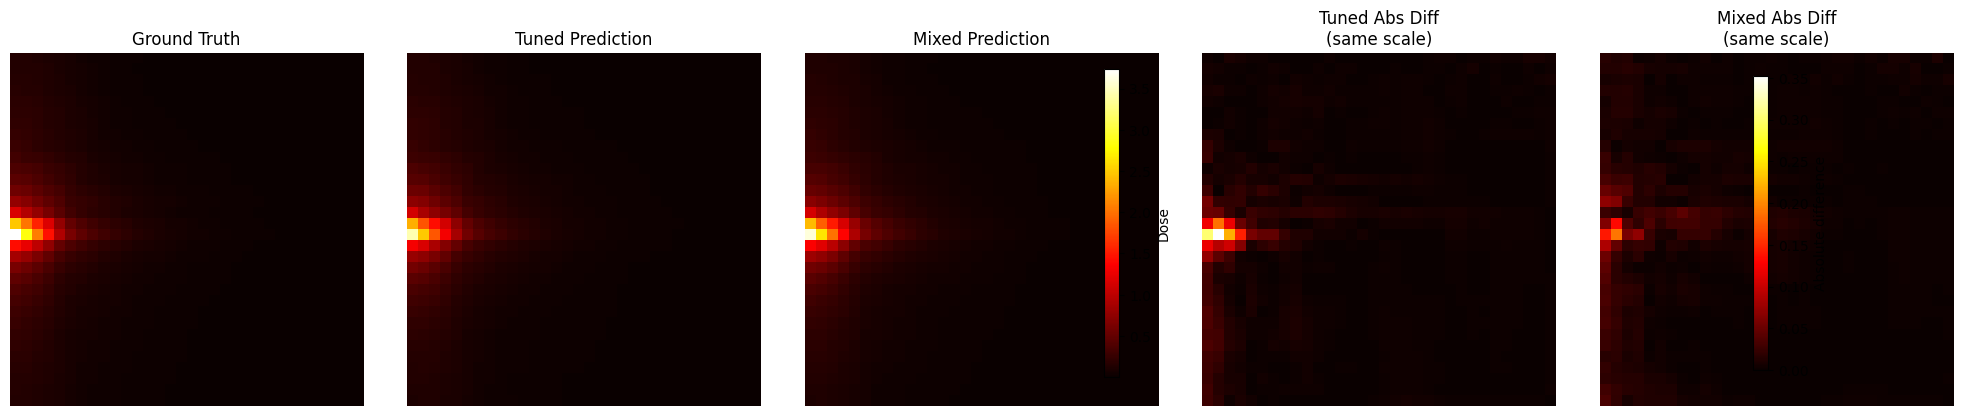

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_worst_sample221_tuned_vs_mixed_full_compare_same_scale_T0p15_a0p30_mw3.png
shared_vmax = 0.35215258598327637


In [15]:
worst_idx = worst_case_idx

ct_vol, gt_vol, tuned_pred = get_flow_prediction(
    tuned_model, val_dataset_3d, worst_idx, device, n_steps=30
)

_, _, mixed_pred = get_flow_prediction(
    mixed_model, val_dataset_3d, worst_idx, device, n_steps=30
)

slice_idx = find_best_dose_slice_index(gt_vol)

gt_slice = gt_vol[slice_idx]
tuned_slice = tuned_pred[slice_idx]
mixed_slice = mixed_pred[slice_idx]

tuned_abs_diff = np.abs(tuned_slice - gt_slice)
mixed_abs_diff = np.abs(mixed_slice - gt_slice)

shared_vmin = 0.0
shared_vmax = max(float(tuned_abs_diff.max()), float(mixed_abs_diff.max()))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

gt_vmin = float(gt_slice.min())
gt_vmax = float(gt_slice.max())

im0 = axes[0].imshow(gt_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

im1 = axes[1].imshow(tuned_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[1].set_title("Tuned Prediction")
axes[1].axis("off")

im2 = axes[2].imshow(mixed_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[2].set_title("Mixed Prediction")
axes[2].axis("off")

im3 = axes[3].imshow(tuned_abs_diff, cmap="hot", vmin=shared_vmin, vmax=shared_vmax)
axes[3].set_title("Tuned Abs Diff\n(same scale)")
axes[3].axis("off")

im4 = axes[4].imshow(mixed_abs_diff, cmap="hot", vmin=shared_vmin, vmax=shared_vmax)
axes[4].set_title("Mixed Abs Diff\n(same scale)")
axes[4].axis("off")

cbar1 = fig.colorbar(im2, ax=axes[:3], fraction=0.025, pad=0.02)
cbar1.set_label("Dose")

cbar2 = fig.colorbar(im4, ax=axes[3:], fraction=0.025, pad=0.02)
cbar2.set_label("Absolute difference")

plt.tight_layout()

same_scale_compare_path = OUT_DIR / f"ct2dose_worst_sample{worst_idx}_tuned_vs_mixed_full_compare_same_scale_T0p15_a0p30_mw3.png"
plt.savefig(same_scale_compare_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", same_scale_compare_path)
print("shared_vmax =", shared_vmax)

### Step 16 — Card 2 table for Trello

In [16]:
card2_table = summary_df[
    [
        "model",
        "overall_mae",
        "weighted_mse",
        "high_mae",
        "outside_mae",
        "outside_max_abs_error",
        "peak_core_mae",
        "peak_shoulder_mae",
    ]
].copy()

card2_table["model"] = pd.Categorical(
    card2_table["model"],
    categories=["tuned", "mixed"],
    ordered=True
)
card2_table = card2_table.sort_values("model").reset_index(drop=True)

card2_table_fmt = card2_table.copy()
for col in card2_table_fmt.columns:
    if col != "model":
        card2_table_fmt[col] = card2_table_fmt[col].map(lambda x: f"{x:.6f}")

display(card2_table_fmt)

card2_csv = OUT_DIR / "ct2dose_card2_summary_table_for_trello_T0p15_a0p30_mw3.csv"
card2_table_fmt.to_csv(card2_csv, index=False)

print("Saved:", card2_csv)
print(card2_table_fmt.to_markdown(index=False))

,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.002662,0.000029,0.006105,0.002506,0.033767,0.047654,0.022622
1,mixed,0.002737,0.000028,0.006276,0.002566,0.036794,0.047260,0.019714


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_mixed_vs_tuned_eval_T0p15_a0p30_mw3/ct2dose_card2_summary_table_for_trello_T0p15_a0p30_mw3.csv
| model   |   overall_mae |   weighted_mse |   high_mae |   outside_mae |   outside_max_abs_error |   peak_core_mae |   peak_shoulder_mae |
|:--------|--------------:|---------------:|-----------:|--------------:|------------------------:|----------------:|--------------------:|
| tuned   |      0.002662 |        2.9e-05 |   0.006105 |      0.002506 |                0.033767 |        0.047654 |            0.022622 |
| mixed   |      0.002737 |        2.8e-05 |   0.006276 |      0.002566 |                0.036794 |        0.04726  |            0.019714 |
